In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

In [2]:
repatriations = pd.read_excel("KHSM Repatriations fy25m11.xlsx", sheet_name=None)

In [3]:
repatriations.keys()

dict_keys(['Annual Repatriations', 'Monthly Repatriations', 'Annual Repatriation Type', 'Monthly Repatriation Type', 'Annual Criminal', 'Monthly Criminal', 'Annual Arrest Location', 'Monthly Arrest Location', 'Annual Citizenship', 'Monthly Citizenship', 'Annual Repatriation Agency', 'Monthly Repatriation Agency', 'Annual Type & Dtl Type', 'Monthly Type & Dtl Type', 'Annual Type & Criminal', 'Monthly Type & Criminal', 'Annual Type & Arrest Loc', 'Monthly Type & Arr Loc', 'Annual Type & Citp', 'Monthly Type & Citp', 'Annual Typ & Rep Agency', 'Monthly Typ & Rep Agency'])

In [4]:
encounters2023 = pd.read_csv("nationwide-encounters-fy20-fy23-aor.csv")
encounters2022 = encounters2023[encounters2023["Fiscal Year"] != 2023]
encounters2326 = pd.read_csv("nationwide-encounters-fy23-fy26-jan-aor.csv")
encounters2326["Fiscal Year"] = encounters2326["Fiscal Year"].apply(lambda x: 2026 if ("2026" in x) else int(x))

In [5]:
encounters = pd.concat([encounters2022,  encounters2326], axis=0)

In [6]:
encounters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83920 entries, 0 to 46582
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Fiscal Year             83920 non-null  int64 
 1   Month Grouping          83920 non-null  object
 2   Month (abbv)            83920 non-null  object
 3   Component               83920 non-null  object
 4   Land Border Region      83920 non-null  object
 5   Area of Responsibility  83920 non-null  object
 6   AOR (Abbv)              83920 non-null  object
 7   Demographic             83920 non-null  object
 8   Citizenship             83920 non-null  object
 9   Title of Authority      83920 non-null  object
 10  Encounter Type          83920 non-null  object
 11  Encounter Count         83920 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 8.3+ MB


In [7]:
encounters["Month Grouping"].unique()

array(['FYTD', 'Remaining'], dtype=object)

In [8]:
encounters.rename(columns={"Month (abbv)":"Month", "Fiscal Year":"Year"}, inplace=True)

In [9]:
encounters["Month"].unique()

array(['APR', 'AUG', 'DEC', 'FEB', 'JAN', 'JUL', 'JUN', 'MAR', 'MAY',
       'NOV', 'OCT', 'SEP'], dtype=object)

In [10]:
encounters["Month"] = encounters["Month"].apply((lambda x: int(next(m for m in repatriations["Monthly Repatriations"]["Month"].unique() if x.lower() in m.lower())[:2])))

In [11]:
encounters["Date"] = pd.to_datetime(encounters[['Year', 'Month']].assign(DAY=1))

In [12]:
for key in repatriations.keys():
    if "monthly" in key.lower():
        repatriations[key]["Month"] =  repatriations[key]["Month"].apply(lambda x: int(x[:2]))
        repatriations[key].rename(columns={"Fiscal\nYear":"Year"}, inplace=True)
        repatriations[key]["Date"] = pd.to_datetime(repatriations[key][['Year', 'Month']].assign(DAY=1))

In [13]:
monthly_repatriations = repatriations["Monthly Repatriations"]

In [14]:
monthly_repatriations.columns

Index(['Year', 'Month', 'Quantity', 'Date'], dtype='object')

In [15]:
monthly_encounters = encounters.groupby("Date")["Encounter Count"].sum()

Text(0, 0.5, 'Ratio')

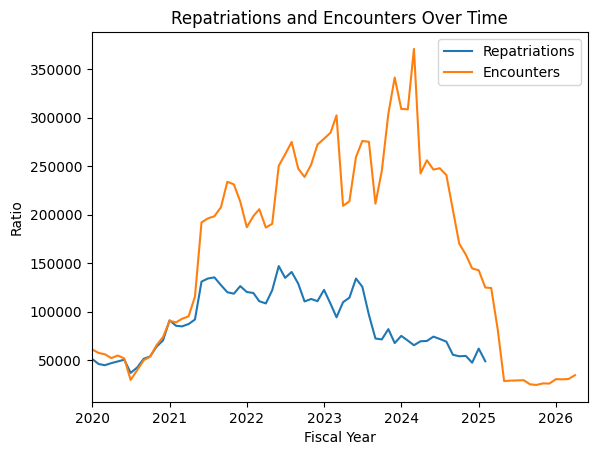

In [ ]:
fig, ax = plt.subplots()
ax.plot(monthly_repatriations["Date"], monthly_repatriations["Quantity"], label="Repatriations")
ax.plot(monthly_encounters.index, monthly_encounters.values, label="Encounters")
ax.legend()
ax.set_xlim([datetime.date(2019, 12, 31), datetime.date(2026, 6, 1)])
ax.set_title("Repatriations and Encounters Over Time")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Ratio")

In [17]:
repats_encounters = pd.merge(monthly_repatriations, monthly_encounters, on="Date", how="right")

In [18]:
repats_encounters["Ratio"] = repats_encounters["Quantity"]/repats_encounters["Encounter Count"]

Text(0, 0.5, 'Ratio')

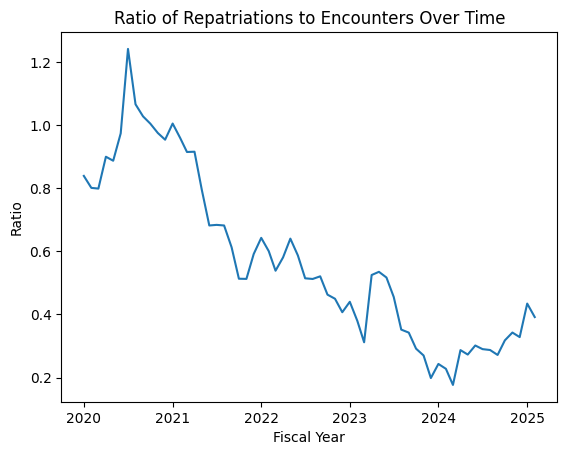

In [29]:
fig, ax = plt.subplots()
ax.plot(repats_encounters["Date"], repats_encounters["Ratio"])
ax.set_title("Ratio of Repatriations to Encounters Over Time")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Ratio")

In [20]:
repatriations["Monthly Repatriation Type"].columns

Index(['Year', 'Month', 'Repatriation Type', 'Quantity', 'Date'], dtype='object')

In [21]:
repatriations["Monthly Repatriation Type"]["Repatriation Type"].unique()

array(['Administrative Returns', 'Enforcement Returns', 'Removals',
       'Title 42 Expulsions'], dtype=object)

In [22]:
title_42_repats = repatriations["Monthly Repatriation Type"][repatriations["Monthly Repatriation Type"]["Repatriation Type"] == "Title 42 Expulsions"]
monthly_title_42_repats = title_42_repats.groupby("Date")["Quantity"].sum()

In [23]:
title_42_encounters = encounters[encounters["Title of Authority"] == "Title 42"]
monthly_title_42_encounters = title_42_encounters.groupby("Date")["Encounter Count"].sum()

In [24]:
title_42_repats_encounters = pd.merge(monthly_title_42_repats, monthly_title_42_encounters, on="Date")

In [25]:
title_42_repats_encounters["Ratio"] = title_42_repats_encounters["Quantity"]/title_42_repats_encounters["Encounter Count"]

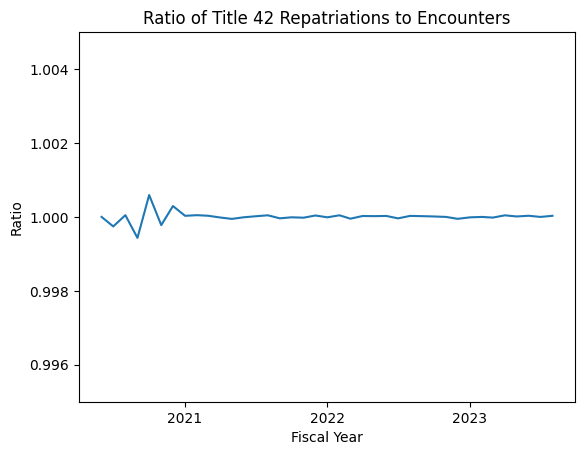

In [27]:
fig, ax = plt.subplots()
ax.plot(title_42_repats_encounters["Ratio"])
ax.set_title("Ratio of Title 42 Repatriations to Encounters")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Ratio")
ax.set_ylim([.995, 1.005])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
